<a href="https://colab.research.google.com/github/garimayadav97/EWP_Health/blob/main/RF_SENTINEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install geemap rasterio scikit-learn geopandas pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.5 MB/s eta 0:00:00


In [ ]:
!pip install pyproj

In [2]:
import geemap
import ee
import geopandas as gpd
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [3]:
ee.Authenticate()
ee.Initialize(project='ee-garimayadav')

In [4]:
import geemap
import pandas as pd
import geopandas as gpd
import ee

# Initialize Google Earth Engine
ee.Initialize()

# Load the Excel file with central points
file_path = '/content/FieldData_CentralPoints_Corrected_with_Height_Class.xlsx'

central_points_df = pd.read_excel(file_path, sheet_name='Data')

# Separate Vermont and Maine/New Hampshire points
vermont_df = central_points_df[central_points_df['States'] == 'VT']
maine_nh_df = central_points_df[central_points_df['States'].isin(['ME', 'NH'])]

# Convert each DataFrame to a GeoDataFrame in the appropriate UTM zone
vermont_gdf = gpd.GeoDataFrame(
    vermont_df,
    geometry=gpd.points_from_xy(vermont_df['Central X'], vermont_df['Central Y']),
    crs="EPSG:32618"  # UTM Zone 18N for Vermont
)

maine_nh_gdf = gpd.GeoDataFrame(
    maine_nh_df,
    geometry=gpd.points_from_xy(maine_nh_df['Central X'], maine_nh_df['Central Y']),
    crs="EPSG:32619"  # UTM Zone 19N for Maine and New Hampshire
)

# Reproject both to EPSG:4326 (WGS84) for compatibility with geemap and map merging
vermont_gdf = vermont_gdf.to_crs(epsg=4326)
maine_nh_gdf = maine_nh_gdf.to_crs(epsg=4326)

# Combine the GeoDataFrames
combined_gdf = pd.concat([vermont_gdf, maine_nh_gdf])

# Step 1: Define boundaries for Vermont, Maine, and New Hampshire
states = ee.FeatureCollection("TIGER/2018/States")
vermont = states.filter(ee.Filter.eq("NAME", "Vermont"))
maine = states.filter(ee.Filter.eq("NAME", "Maine"))
new_hampshire = states.filter(ee.Filter.eq("NAME", "New Hampshire"))

# Combine the regions into one FeatureCollection
combined_region = vermont.merge(maine).merge(new_hampshire)

# Step 2: Define date range for Sentinel-2 data
start_date = '2024-05-15'
end_date = '2024-08-30'

# Step 3: Cloud Masking Function (from Sentinel-2 QA band)
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    return image.updateMask(mask).select("B.*").copyProperties(image, ["system:time_start"])


#S2 SR masking using Scene Classification Layer (SCL),
def mask_s2_sr_clouds(image):
    # Scene Classification Layer (SCL)
    scl = image.select('SCL')
    cloud_shadow = scl.eq(3)  # Cloud shadow
    clouds_high = scl.eq(9)  # Clouds
    clouds_medium = scl.eq(8)  # Cirrus
    # Combine mask
    cirrus = scl.eq(10)  # Cirrus


    # Combine mask
    mask = scl.eq(4)  # Mask out clouds and shadows

    # Update mask and return scaled reflectance
    return image.updateMask(mask).divide(10000)


# Load Sentinel-2 ImageCollection for Combined Region with cloud masking

# Apply this function to your collection
sentinel2_collection = (ee.ImageCollection('COPERNICUS/S2_SR')
                        .filterDate(start_date, end_date)
                        .filterBounds(combined_region)
                        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
                        .map(mask_s2_sr_clouds))


# Create a median composite of the cloud-free images
image_median = sentinel2_collection.median().clip(combined_region)

# Set up visualization parameters
vis_params  = {'bands': ['B8', 'B4', 'B3'], 'min': 0, 'max': 1, 'gamma': 1.4}

# Step 4: Display the image and points on a geemap Map
Map = geemap.Map(center=[44.0, -71.5], zoom=7)
#Map.addLayer(image_median, vis_params, 'Sentinel-2 Composite')
Map.addLayer(image_median, vis_params, 'Sentinel-2 Composite')


# Convert GeoDataFrame to Earth Engine FeatureCollection for map display
features = []
for _, row in combined_gdf.iterrows():
    print(row['Plot No'])
    feature = ee.Feature(
        ee.Geometry.Point([row.geometry.x, row.geometry.y]),
        {
                'Plot No': int(row['Plot No']),
                'LAI (LiCOR)': row['LAI (LiCOR)'],
                'LAI (DHP)': row['LAI (DHP)'],
                'State': row['States'],
                'Tree Denisty': row['Tree Density'],
                'Tree Denisty Class': row['Tree Density Class'],
                'DBH': row['DBH'],
                'DBH Class': row['DBH Class'],
                'Canopy Height': row['Canopy Height'],
                'Canopy Height Class': row['Canopy Height Class'],
                'LCR': row['LCR']

            }
    )
    features.append(feature)
central_points_ee = ee.FeatureCollection(features)

# Define a style for the points
point_style = {
    'color': 'yellow',
    'pointSize': 5,
    'pointShape': 'triangle',
    'width': 1
}

#Map.addLayer(image_median.select('SCL'), {'min': 0, 'max': 11}, 'SCL Classification')

# Add points layer to the map
Map.addLayer(central_points_ee.style(**point_style), {}, "Central Points")

# Display the map
Map


/usr/local/lib/python3.11/dist-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for COPERNICUS/S2_SR! You are using a deprecated asset.
To ensure continued functionality, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR

  warnings.warn(warning, category=DeprecationWarning)


75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192


Map(center=[44.0, -71.5], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

In [ ]:
sentinel2_collection

Name,Description
B1,Aerosols
B2,Blue
B3,Green
B4,Red
B5,Red Edge 1
B6,Red Edge 2
B7,Red Edge 3
B8,NIR
B8A,Red Edge 4
B9,Water vapor


In [5]:
# Function to calculate vegetation indices
def calculate_indices(image):

### STRUCTURE

    # NDVI: Normalized Difference Vegetation Index
    NDVI = image.normalizedDifference(['B8', 'B4']).rename('NDVI')

    # EVI: Enhanced Vegetation Index
    EVI = image.expression(
        '2.5 * ((NIR - RED) / (1 + NIR + 6 * RED - 7.5 * BLUE ))',
        {'NIR': image.select('B8'), 'RED': image.select('B4'), 'BLUE': image.select('B2')}
    ).rename('EVI')

    # EVI7: Enhanced Vegetation Index 7
    EVI7 = image.expression(
        '2.5 * ((RE3 - RED) / (1 + RE3 + 6 * RED - 7.5 * BLUE ))',
        {'RE3': image.select('B7'), 'RED': image.select('B4'), 'BLUE': image.select('B2')}
    ).rename('EVI7')

    EVI8 = image.expression(
        '2.5 * ((RE4- RED) / (1 + RE4 + 6 * RED - 7.5 * BLUE ))',
        {'RE4': image.select('B8A'), 'RED': image.select('B4'), 'BLUE': image.select('B2')}
    ).rename('EVI8')

    # SR: Simple Ratio (SR)
    MSR = image.expression(
        '((RE3 / RED)-1) / sqrt((RE3 / RED)+1)',
        {'RE3': image.select('B7'), 'RED': image.select('B4'), 'BLUE': image.select('B2')}
    ).rename('MSR')


### Physiology/stress

    # NDII: Normalized Difference Infrared Index
    NDII11 = image.normalizedDifference(['B8A', 'B11']).rename('NDII11')

    NDII12 = image.normalizedDifference(['B8A', 'B12']).rename('NDII12')

    # CRI1: Carotenoid Reflectance Index1 (CRI1)
    CRI1 = image.expression(
        '( 1 / BLUE ) - ( 1 / GREEN )',
        {'BLUE': image.select('B2'), 'GREEN': image.select('B3')}
    ).rename('CRI1')

    #Plant Senescence Reflectance Index (PSRI)
    PSRI = image.expression(
        '(RED - GREEN)/ NIR',
        {'NIR': image.select('B8A'), 'RED': image.select('B4'), 'GREEN': image.select('B3')}
    ).rename('PSRI')

### Biochemistry

    # IRECI: Infrared Red Edge Chlorophyll Index
    IRECI = image.expression(
        '(B7-B4)*(B6/B5)',
        {'B7': image.select('B7'), 'B4': image.select('B4'), 'B6': image.select('B6'),'B5': image.select('B5')}
        #'(NIR - RED) / (RE1 / RE2)',
        #{'NIR': image.select('B8'), 'RE2': image.select('B6'), 'RE1': image.select('B5'),'RED': image.select('B4')}
    ).rename('IRECI')

    # S2REP: Sentinel-2 Red-Edge Photochemical Reflectance Index
    S2REP = image.expression(
        '705 + 35*((((RE3 + RED)/2)-RE1)/(RE2-RE1))',
        {'RE3': image.select('B7'), 'RE2': image.select('B6'), 'RE1': image.select('B5'),'RED': image.select('B4')}
    ).rename('S2REP')


    # GCI: Green Chlorophyll Index
    GCI = image.expression(
        '(RE4 / GREEN) - 1',
        {'RE4': image.select('B8A'), 'GREEN': image.select('B3')}
    ).rename('GCI')

    # GCI: Green Atmospherically Resistant Index (GARI)
    GARI = image.expression(
        '(RE4-GREEN-(BLUE-RED))/(RE4 + GREEN-(BLUE-RED))',
        {'RE4': image.select('B8A'), 'GREEN': image.select('B3'),'RED': image.select('B4'), 'BLUE': image.select('B2')}
    ).rename('GARI')

    GNDVI = image.normalizedDifference(['B8A', 'B3']).rename('GNDVI')

    # NDVIRE: Normalized Difference Vegetation Index Red Edge
    NDVIRE = image.normalizedDifference(['B8A', 'B6']).rename('NDVIRE')


    # TCARI: Transformed Chlorophyll Absorption Ratio Index
    TCARI = image.expression(
        '3*((RE1-RED)-0.2*(RE1-GREEN)*(RE1/RED))',
        {'RE1': image.select('B5'), 'GREEN': image.select('B3'),'RED': image.select('B4'), 'BLUE': image.select('B2')}
    ).rename('TCARI')


    MCARI =  image.expression(
        '(RE2 - RE1) - 0.2 * (RE2 - RED) * RE2 / RE1',
        {'RE1': image.select('B5'), 'RE2': image.select('B6'),'RED': image.select('B4')}
    ).rename('MCARI')



    # Combine all indices into a single image
    indices_image = image.addBands([NDVI, EVI, EVI7, EVI8, MSR, CRI1,NDII11,NDII12, PSRI, GCI, GARI, GNDVI, IRECI, S2REP, NDVIRE, TCARI, MCARI])


    return indices_image


In [6]:

# Apply calculate_indices to the Sentinel-2 collection

sentinel2_with_indices = sentinel2_collection.map(calculate_indices)

# Create a median composite image
composite_image = sentinel2_with_indices.median().clip(combined_region)


# Debug: Check bands in composite image
print("Bands in composite image:", composite_image.bandNames().getInfo())

def extract_indices(feature):
    reducer = ee.Reducer.first()
    indices = composite_image.reduceRegion(
        reducer=reducer,
        geometry=feature.geometry(),
        scale=10,
        maxPixels=1e9
    )
    # Use set() directly without any client-side operations
    return feature.set(indices)



# Extract values for each point
def extract_values_for_point(feature):
    # Reduce the image to extract all bands and indices at the point
    region_values = bands_and_indices.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=feature.geometry(),
        scale=10
    )
    # Return a dictionary of the extracted values
    return region_values.getInfo()


central_points_ee_with_indices = ee.FeatureCollection(features).map(extract_indices)


# Convert the FeatureCollection to a dictionary
points_dict = central_points_ee_with_indices.getInfo()

# Step 2: Convert to Pandas DataFrame
data = pd.DataFrame([
    {**feature['properties']} for feature in points_dict['features']
])

# Debug: Check the DataFrame structure
print("Columns in DataFrame:", data.columns)
print("Sample extracted data:\n", data.head())

# Step 3: Handle Missing Values
data = data.dropna()


Bands in composite image: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE', 'NDVI', 'EVI', 'EVI7', 'EVI8', 'MSR', 'CRI1', 'NDII11', 'NDII12', 'PSRI', 'GCI', 'GARI', 'GNDVI', 'IRECI', 'S2REP', 'NDVIRE', 'TCARI', 'MCARI']
Columns in DataFrame: Index(['AOT', 'B1', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'B8A', 'B9', 'CRI1', 'Canopy Height', 'Canopy Height Class', 'DBH',
       'DBH Class', 'EVI', 'EVI7', 'EVI8', 'GARI', 'GCI', 'GNDVI', 'IRECI',
       'LAI (DHP)', 'LAI (LiCOR)', 'LCR', 'MCARI', 'MSK_CLASSI_CIRRUS',
       'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_SNOW_ICE', 'MSK_CLDPRB', 'MSK_SNWPRB',
       'MSR', 'NDII11', 'NDII12', 'NDVI', 'NDVIRE', 'PSRI', 'Plot No', 'S2REP',
       'SCL', 'State', 'TCARI', 'TCI_B', 'TCI_G', 'TCI_R', 'Tree Denisty',
       'Tree Denisty Class', 'WVP'],
      dtype='object')

In [ ]:
print(data['PSRI'].max())

-0.015580312348902225


In [7]:
# Define the date ranges for each month
date_ranges = {
    "May": ("2024-05-01", "2024-05-31"),
    "June": ("2024-06-01", "2024-06-30"),
    "July": ("2024-07-01", "2024-07-31"),
    "October": ("2024-10-01", "2024-10-31"),
    "November": ("2024-11-01", "2024-11-30"),
}

# Function to process Sentinel-2 data for a given date range
def process_month(date_range):
    collection = (
        ee.ImageCollection('COPERNICUS/S2_SR')
        .filterDate(*date_range)
        .filterBounds(combined_region)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
        .map(mask_s2_sr_clouds)
        .map(calculate_indices)
    )
    return collection.median().clip(combined_region)

# Process each month's data and store in a dictionary
monthly_composites = {month: process_month(date_range) for month, date_range in date_ranges.items()}

# Function to extract indices for a given composite and add as properties
def extract_indices_for_month(feature, composite, prefix):
    reducer = ee.Reducer.first()
    indices = composite.reduceRegion(
        reducer=reducer,
        geometry=feature.geometry(),
        scale=10,
        maxPixels=1e9
    )
    # Get keys from the ee.Dictionary and map them to prefixed properties
    keys = indices.keys()
    prefixed_properties = keys.map(lambda key: ee.String(prefix).cat("_").cat(key))
    values = indices.values(keys)
    # Use combine to set prefixed properties with corresponding values
    return feature.set(ee.Dictionary.fromLists(prefixed_properties, values))

# Add indices from each month to the feature collection
for month, composite in monthly_composites.items():
    central_points_ee = central_points_ee.map(lambda feature: extract_indices_for_month(feature, composite, month))

# Convert the enriched FeatureCollection to a dictionary
points_dict_with_monthly_indices = central_points_ee.getInfo()

# Convert to a DataFrame
data_m = pd.DataFrame([
    {**feature['properties']} for feature in points_dict_with_monthly_indices['features']
])

# Handle Missing Values (if any)
data = data_m.dropna()

# Save the DataFrame to a file or explore it
print("Sample data with monthly indices:\n", data_m.head())



Sample data with monthly indices:
    Canopy Height Canopy Height Class        DBH DBH Class  June_AOT  June_B1  \
0           22.0              Medium  11.942675    Medium    0.0075   0.1273   
1           27.0              Medium  19.500000    Medium    0.0076   0.1260   
2           30.0                High  19.500000    Medium    0.0076   0.1252   
3           26.0                High  22.250000      High    0.0076   0.1261   
4           27.0                High  23.500000      High    0.0076   0.1255   

   June_B11  June_B12  June_B2  June_B3  ...  May_NDVI  May_NDVIRE  May_PSRI  \
0    0.2274    0.1613   0.1310   0.1511  ...       NaN         NaN       NaN   
1    0.2564    0.1711   0.1314   0.1526  ...       NaN         NaN       NaN   
2    0.2587    0.1712   0.1310   0.1499  ...       NaN         NaN       NaN   
3    0.2538    0.1704   0.1349   0.1526  ...       NaN         NaN       NaN   
4    0.2461    0.1675   0.1334   0.1519  ...       NaN         NaN       NaN   

   

In [ ]:
print(data_m['May_NDVI'].max())

0.6129398345947266


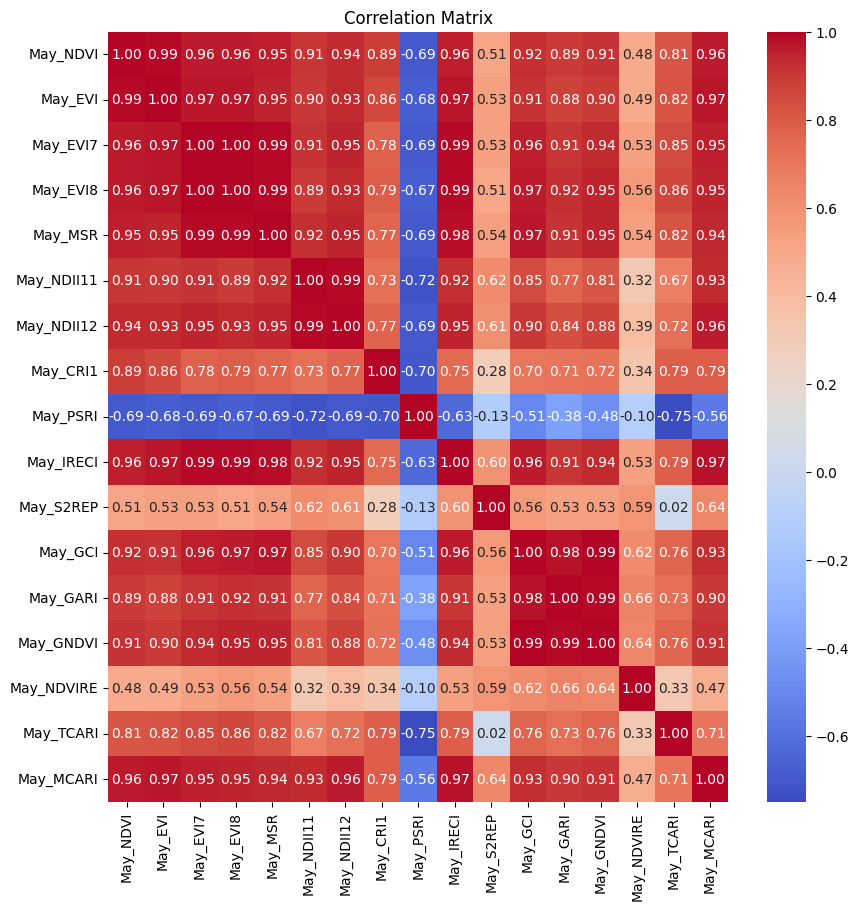

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt



# Select numeric columns for correlation
numeric_columns = ['May_NDVI', 'May_EVI', 'May_EVI7', 'May_EVI8', 'May_MSR', 'May_NDII11', 'May_NDII12',
                   'May_CRI1', 'May_PSRI', 'May_IRECI', 'May_S2REP', 'May_GCI', 'May_GARI', 'May_GNDVI', 'May_NDVIRE', 'May_TCARI', 'May_MCARI']

correlation_matrix = data_m[numeric_columns].corr()

# Display the correlation matrix
#print("Correlation Matrix:\n", correlation_matrix)

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()



       Feature  Importance
8     May_PSRI    0.196946
15   May_TCARI    0.130470
1      May_EVI    0.101927
12    May_GARI    0.079740
10   May_S2REP    0.069551
13   May_GNDVI    0.061948
2     May_EVI7    0.044707
5   May_NDII11    0.042087
14  May_NDVIRE    0.041858
0     May_NDVI    0.038228
11     May_GCI    0.037275
16   May_MCARI    0.035966
3     May_EVI8    0.032374
4      May_MSR    0.031559
7     May_CRI1    0.024681
9    May_IRECI    0.017112
6   May_NDII12    0.013570


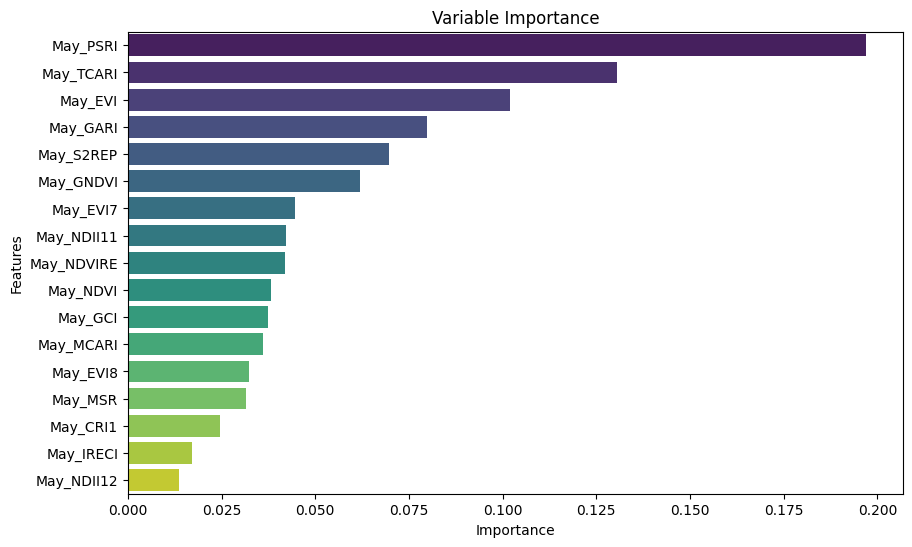

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Assuming `data` has a target column named 'Target'
target_column = 'LAI (DHP)'  # Replace with the actual target column name
X = data[numeric_columns]
y = data[target_column]

# Train a Random Forest model
rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

# Get feature importances
feature_importances = pd.DataFrame({
    'Feature': numeric_columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display feature importances
print(feature_importances)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title('Variable Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()


In [ ]:
# Export to a single Excel sheet
output_file = 'indices_values.xlsx'
data.to_excel(output_file, sheet_name='All_Indices', index=False)

print(f"Data exported successfully to {output_file}")


Data exported successfully to indices_values.xlsx


In [ ]:
# Step 3: Load Sentinel-1 GRD ImageCollection
s1_collection = (ee.ImageCollection('COPERNICUS/S1_GRD')
                        .filterDate(start_date, end_date)
                        .filter(ee.Filter.eq('instrumentMode', 'IW'))  # Interferometric Wide Swath
                        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
                        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
                        .filterBounds(combined_region))

# Load DEM and calculate slope and aspect
dem = ee.Image('USGS/SRTMGL1_003')  # Digital Elevation Model
slope = ee.Terrain.slope(dem).rename('slope')
aspect = ee.Terrain.aspect(dem).rename('aspect')

# Add radar geometry (elevation angle, slope, aspect)
def add_radar_geometry(image):
    elevation_angle = image.select('angle')  # Radar incidence angle
    terrain_slope = slope.multiply(3.14159265359/180)  # Convert slope to radiansc
    terrain_aspect = aspect.multiply(3.14159265359/180)  # Convert aspect to radians
    return image.addBands(elevation_angle).addBands(terrain_slope).addBands(terrain_aspect)

# Terrain flattening function
def terrain_flattening(image):
    radar_incidence_angle = image.select('angle').multiply(3.14159265359/180)  # Convert to radians
    terrain_slope = image.select('slope')
    cos_theta = radar_incidence_angle.cos()
    cos_alpha = terrain_slope.cos()

    # Radiometric terrain normalization
    vv_normalized = image.select('VV').divide(cos_theta).multiply(cos_alpha).rename('VV_flattened')
    vh_normalized = image.select('VH').divide(cos_theta).multiply(cos_alpha).rename('VH_flattened')

    return image.addBands([vv_normalized, vh_normalized])

# Apply radar geometry and terrain flattening
s1_preprocessed = s1_collection.map(add_radar_geometry).map(terrain_flattening)

# Create a median composite
s1_composite = s1_preprocessed.median().clip(combined_region)

vv_vh_ratio = s1_composite.expression(
    'VV / VH', {
        'VV': s1_composite.select('VV_flattened'),
        'VH': s1_composite.select('VH_flattened')
    }
).rename('VV_VH_Ratio')

sqrt_vv_vh = s1_composite.expression(
    # Avoid division by zero by adding a small constant to VH
    'sqrt(VV / (VH + 1e-6))', {
        'VV': s1_composite.select('VV_flattened'),
        'VH': s1_composite.select('VH_flattened')
    }
).rename('Sqrt_VV_VH')

sqrt_vv_times_vh = s1_composite.expression(
    'sqrt(VV * VH)', {
        'VV': s1_composite.select('VV_flattened'),
        'VH': s1_composite.select('VH_flattened')
    }
).rename('Sqrt_VV_Times_VH')

vv_times_vh = s1_composite.expression(
    'VV * VH', {
        'VV': s1_composite.select('VV_flattened'),
        'VH': s1_composite.select('VH_flattened')
    }
).rename('VV_Times_VH')

# Combine bands with derived metrics
combined_s1_image = (s1_composite
                  .addBands(vv_vh_ratio)
                  .addBands(sqrt_vv_vh)
                  .addBands(sqrt_vv_times_vh).addBands(vv_times_vh))

In [ ]:
def extract_s1_indices(feature):
    reducer = ee.Reducer.first()
    indices = combined_s1_image.reduceRegion(
        reducer=reducer,
        geometry=feature.geometry(),
        scale=10,
        maxPixels=1e9
    )
    return feature.set(indices)


In [ ]:
# Process Sentinel-1 FeatureCollection for extracting values
s1_points_ee = ee.FeatureCollection(features).map(extract_s1_indices)

# Convert Sentinel-1 FeatureCollection to a dictionary
s1_points_dict = s1_points_ee.getInfo()

# Convert Sentinel-1 data to Pandas DataFrame
s1_data = pd.DataFrame([
    {**feature['properties']} for feature in s1_points_dict['features']
])

# Debug: Check Sentinel-1 DataFrame structure
print("Columns in Sentinel-1 DataFrame:", s1_data.columns)
print("Sample Sentinel-1 extracted data:\n", s1_data.head())

# Handle missing values for Sentinel-1 data
s1_data = s1_data.dropna()

# Combine Sentinel-2 and Sentinel-1 DataFrames
merged_data = pd.merge(data, s1_data, on='Plot No', suffixes=('_S2', '_S1'))

# Export the combined data to an Excel file
with pd.ExcelWriter('indices_values.xlsx', engine='openpyxl', mode='w') as writer:
    merged_data.to_excel(writer, sheet_name='All_Indices', index=False)

print(f"Data from Sentinel-1 and Sentinel-2 exported successfully to 'indices_values.xlsx'")


Columns in Sentinel-1 DataFrame: Index(['Canopy Height', 'Canopy Height Class', 'DBH', 'DBH Class', 'LAI (DHP)',
       'LAI (LiCOR)', 'LCR', 'Plot No', 'Sqrt_VV_Times_VH', 'Sqrt_VV_VH',
       'State', 'Tree Denisty', 'Tree Denisty Class', 'VH', 'VH_flattened',
       'VV', 'VV_Times_VH', 'VV_VH_Ratio', 'VV_flattened', 'angle', 'angle_1',
       'aspect', 'slope'],
      dtype='object')
Sample Sentinel-1 extracted data:
    Canopy Height Canopy Height Class        DBH DBH Class  LAI (DHP)  \
0           22.0              Medium  11.942675    Medium   4.313333   
1           27.0              Medium  19.500000    Medium   3.930000   
2           30.0                High  19.500000    Medium   4.130000   
3           26.0                High  22.250000      High   3.973333   
4           27.0                High  23.500000      High   3.743333   

   LAI (LiCOR)       LCR  Plot No  Sqrt_VV_Times_VH  Sqrt_VV_VH  ...  \
0         3.18  0.590909       75         15.072858    0.835294  ... 

In [ ]:
# Validate that Sentinel-1 and Sentinel-2 data align
print("Sample Sentinel-2 Data:\n", data.head())
print("Sample Sentinel-1 Data:\n", s1_data.head())

# Validate merged data
print("Sample Merged Data:\n", merged_data.head())

# Check for mismatched records
missing_s2 = s1_data[~s1_data['Plot No'].isin(data['Plot No'])]
missing_s1 = data[~data['Plot No'].isin(s1_data['Plot No'])]
print("Missing Sentinel-2 Data for Plots:\n", missing_s2)
print("Missing Sentinel-1 Data for Plots:\n", missing_s1)


Sample Sentinel-2 Data:
     Canopy Height Canopy Height Class        DBH DBH Class  June_AOT  June_B1  \
31           20.0                Low   10.509554    Medium    0.0098   0.1315   
32           25.0                Low   19.108280    Medium    0.0098   0.1279   
33           30.0                Low   12.738854    Medium    0.0098   0.1352   
36           25.0              Medium   9.235669       Low    0.0098   0.1267   
37           27.0              Medium  14.331210    Medium    0.0098   0.1285   

    June_B11  June_B12  June_B2  June_B3  ...  May_NDVI  May_NDVIRE  May_PSRI  \
31    0.2707    0.1877   0.1331   0.1642  ...  0.369676    0.086899 -0.005952   
32    0.2479    0.1678   0.1308   0.1520  ...  0.456790    0.066982 -0.066519   
33    0.2750    0.1817   0.1291   0.1570  ...  0.389852    0.109749 -0.044732   
36    0.2713    0.1784   0.1282   0.1540  ...  0.441556    0.080143 -0.027537   
37    0.2668    0.1770   0.1280   0.1552  ...  0.456871    0.072207 -0.039880   

 

In [ ]:
# Load USGS SRTM DEM
dem = ee.Image('USGS/SRTMGL1_003')

# Resample DEM to 10m resolution
dem_resampled = dem.resample('bilinear').reproject(crs=dem.projection(), scale=10)

# Calculate slope
slope_10m = ee.Terrain.slope(dem_resampled).rename('slope_10m')

# Combine elevation and slope into a single image
terrain_data = dem_resampled.rename('elevation_10m').addBands(slope_10m)


In [ ]:
def extract_terrain_data(feature):
    reducer = ee.Reducer.first()
    terrain_values = terrain_data.reduceRegion(
        reducer=reducer,
        geometry=feature.geometry(),
        scale=10,
        maxPixels=1e9
    )
    return feature.set(terrain_values)

# Apply terrain data extraction function to features
terrain_points_ee = ee.FeatureCollection(features).map(extract_terrain_data)

# Convert FeatureCollection to a dictionary
terrain_points_dict = terrain_points_ee.getInfo()

# Convert to Pandas DataFrame
terrain_data_df = pd.DataFrame([
    {**feature['properties']} for feature in terrain_points_dict['features']
])

# Handle missing values
terrain_data_df = terrain_data_df.dropna()

# Debug: Check terrain DataFrame
print("Columns in Terrain DataFrame:", terrain_data_df.columns)
print("Sample Terrain Data:\n", terrain_data_df.head())


Columns in Terrain DataFrame: Index(['Canopy Height', 'Canopy Height Class', 'DBH', 'DBH Class', 'LAI (DHP)',
       'LAI (LiCOR)', 'LCR', 'Plot No', 'State', 'Tree Denisty',
       'Tree Denisty Class', 'elevation_10m', 'slope_10m'],
      dtype='object')
Sample Terrain Data:
    Canopy Height Canopy Height Class        DBH DBH Class  LAI (DHP)  \
0           22.0              Medium  11.942675    Medium   4.313333   
1           27.0              Medium  19.500000    Medium   3.930000   
2           30.0                High  19.500000    Medium   4.130000   
3           26.0                High  22.250000      High   3.973333   
4           27.0                High  23.500000      High   3.743333   

   LAI (LiCOR)       LCR  Plot No State  Tree Denisty Tree Denisty Class  \
0         3.18  0.590909       75    VT             2               Low    
1         5.04  0.481481       76    VT             4             Medium   
2         3.87  0.500000       77    VT             5       

In [ ]:
# Merge terrain data with existing Sentinel data
final_data = pd.merge(merged_data, terrain_data_df, on='Plot No', suffixes=('', '_terrain'))

# Export final data to Excel
output_file = 'indices_values_with_terrain.xlsx'
with pd.ExcelWriter(output_file, engine='openpyxl', mode='w') as writer:
    final_data.to_excel(writer, sheet_name='All_Data', index=False)

print(f"Final data with elevation and slope exported successfully to {output_file}")


Final data with elevation and slope exported successfully to indices_values_with_terrain.xlsx


In [ ]:
import pandas as pd
import numpy as np
import random
data = pd.read_excel('/content/indices_values_with_terrain.xlsx', sheet_name='All_Data')
features = data[['May_S2REP','June_S2REP','July_S2REP','October_S2REP','November_S2REP','May_NDII11','June_NDII11','July_NDII11','October_NDII11','November_NDII11',"elevation_10m"]]

data = data.dropna()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
from sklearn.model_selection import train_test_split
target = data['LAI (LiCOR)']  # Example target variable
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=26, random_state=42, max_depth= 10, min_samples_leaf= 2)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")
print(model.get_params())


Mean Squared Error: 1.2221979732503456
R2 Score: 0.3194699333220048
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 10, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 26, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'max_depth': [None, 10, 20, 30],  # Maximum depth of trees
    'min_samples_split': [2, 5, 10],  # Minimum samples to split an internal node
    'min_samples_leaf': [1, 2, 4],  # Minimum samples in a leaf node
    'max_features': ['sqrt', 'log2', None]  # Number of features to consider at each split
}

# Initialize the Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='r2', verbose=2, n_jobs=-1)

# Perform the grid search
grid_search.fit(X_train, y_train)

# Get the best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation R2 Score: {best_score}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validation R2 Score: -0.3331109429471399


In [ ]:
from sklearn.svm import SVR

# Initialize and train the regressor
svm_regressor = SVR(kernel='rbf', C=1.0, gamma='scale')
svm_regressor.fit(X_train, y_train)

# Predict
y_pred = svm_regressor.predict(X_test)

# Evaluate
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")


Mean Squared Error: 1.4184500736113739
R² Score: -0.008241662902584324


In [ ]:
import pandas as pd



# Example thresholds for LAI (modify these based on your data distribution)
bins = [0,2,3.5,6]  # Define edges for each class (e.g., 0-1: Very Low, 1-2: Low, etc.)
labels = [0,1,2]  # Class labels

# Assuming 'LAI' is the column with LAI values
data['LAI_Class'] = pd.cut(data['LAI (LiCOR)'], bins=bins, labels=labels, right=False)

# Inspect the updated DataFrame
print(data[['LAI (LiCOR)','LAI_Class']].head())
print(data['LAI_Class'].value_counts())


   LAI (LiCOR) LAI_Class
0         3.18         1
1         5.04         2
2         3.87         2
3         3.21         1
4         3.66         2
LAI_Class
1    82
2    53
0    43
Name: count, dtype: int64


In [ ]:
from sklearn.svm import SVC

import pandas as pd



features = data[['elevation_10m', 'S2REP']]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
from sklearn.model_selection import train_test_split
#target = data['LAI']  # Example target variable
#X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.2, random_state=42)

target_class = data['LAI_Class']  # Example target variable

X_train, X_test, y_train, y_test = train_test_split(features_scaled, target_class, test_size=0.3, random_state=42)

In [ ]:
# Initialize and train the classifier
svm_classifier = SVC(kernel='linear', C=1.0, gamma='scale', random_state=42)
svm_classifier.fit(X_train, y_train)
from sklearn.svm import SVR

# Initialize and train the regressor
svm_regressor = SVR(kernel='linear', C=1.0, gamma='scale')
svm_regressor.fit(X_train, y_train)
from sklearn.metrics import accuracy_score, classification_report


# Make predictions
y_pred = svm_classifier.predict(X_test)


from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")


# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print("Classification Report:\n", classification_report(y_test, y_pred))

Mean Squared Error: 0.7777777777777778
R2 Score: -0.35564853556485354
Accuracy: 0.3333333333333333
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        16
           1       0.38      0.78      0.51        23
           2       0.00      0.00      0.00        15

    accuracy                           0.33        54
   macro avg       0.13      0.26      0.17        54
weighted avg       0.16      0.33      0.22        54



In [ ]:

from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")


Mean Squared Error: 0.4548389174802637
R2 Score: 0.2072263697713992


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler


features = data[['S2REP', 'NDII11','elevatimicron_10m']]
target = data['LAI (LiCOR)']  # Example target variable

# Remove missing values
data = data.dropna()



# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Initialize XGBoost regressor
xgb = XGBRegressor(random_state=42)

# Train the XGBoost model
xgb.fit(X_train, y_train)

# Predictions
y_pred = xgb.predict(X_test)
print(y_pred)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")


[3.220616  3.5248296 3.076471  2.5053399 4.180608  2.09591   1.3834196
 3.133283  2.0643952 3.1710696 1.9878626 3.0395908 3.9637072 1.7315888
 2.0097034 2.1505141 2.1239104 4.057822  4.1117616 2.514961  3.0469084
 2.8832753 3.365947  1.7315888 2.4501162 2.540446  1.4165592 3.0111728
 2.9357727 3.0574107 3.0797179 3.696621  2.6043024 3.0855377 3.831131
 3.3788433]
Mean Squared Error: 1.2339164191943421
R2 Score: 0.12292581493272925


In [ ]:
# Filter rows where the target variable (LAI) is within the desired range
filtered_data = data[(data['LAI (LiCOR)'] >0.8) & (data['LAI (LiCOR)'] <=5)]  # Replace 'LCR' with 'LAI' if that's the actual column name
# Update features and target
features = data[['S2REP', 'NDII11','elevation_10m']]  # Features
target = data['LAI (LiCOR)']  # Target variable (e.g., LAI)

# Scale the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Split the filtered data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.2, random_state=42)

# Proceed with XGBoost
from xgboost import XGBRegressor
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)

# Predict and evaluate
y_pred = xgb.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")


Mean Squared Error: 0.6032890006206565
R2 Score: 0.3350777897566707


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# Load data
data = pd.read_excel('indices_values_with_terrain_1.xlsx', sheet_name='Sheet1')
features = data[['S2REP', 'elevation_10m', ]]
target = data['LAI (LiCOR)']  # Example target variable

# Drop missing values
data = data.dropna()

# Scale features
feature_scaler = StandardScaler()
features_scaled = feature_scaler.fit_transform(features)

# Scale the target variable
target_scaler = MinMaxScaler()  # Use StandardScaler() for standard scaling
target_scaled = target_scaler.fit_transform(target.values.reshape(-1, 1))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target_scaled, test_size=0.2, random_state=42)

# Initialize and train XGBoost model
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train.ravel())  # Flatten target for training

# Predict scaled values
y_pred_scaled = xgb.predict(X_test)

# Inverse transform predictions to original scale
y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_original = target_scaler.inverse_transform(y_test)

# Evaluate the model
mse = mean_squared_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")


Mean Squared Error: 1.110818830641077
R2 Score: -0.04233660652017934


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load data
features = data[['S2REP', 'NDII11','elevation_10m']]
target = data['LAI (LiCOR)']  # Example target variable

# Drop missing values
data = data.dropna()

# Scale features
feature_scaler = StandardScaler()
features_scaled = feature_scaler.fit_transform(features)

# Scale the target variable
target_scaler = MinMaxScaler()  # Use StandardScaler() for standard scaling
target_scaled = target_scaler.fit_transform(target.values.reshape(-1, 1))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target_scaled, test_size=0.2, random_state=42)

# Define the ANN model
model = Sequential()
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))  # First hidden layer
model.add(Dense(32, activation='relu'))  # Second hidden layer
model.add(Dense(1, activation='linear'))  # Output layer for regression

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=1)

# Predict and inverse transform predictions
y_pred_scaled = model.predict(X_test)
y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_test_original = target_scaler.inverse_transform(y_test)

# Evaluate the model
mse = mean_squared_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 185ms/step - loss: 0.4006 - mae: 0.5746 - val_loss: 0.1847 - val_mae: 0.3763
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.2196 - mae: 0.3966 - val_loss: 0.1263 - val_mae: 0.3069
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1463 - mae: 0.3174 - val_loss: 0.1237 - val_mae: 0.2895
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1255 - mae: 0.2836 - val_loss: 0.1206 - val_mae: 0.2927
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0851 - mae: 0.2315 - val_loss: 0.1104 - val_mae: 0.2873
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0791 - mae: 0.2207 - val_loss: 0.0990 - val_mae: 0.2707
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0831 - mae: 0.2364 - val_loss: 0.0920 - val_mae: 0.2524
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0855 - mae: 0.2345 - val_loss: 0.0864 - val_mae: 0.2396
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0842 - mae: